In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import itertools
import cv2
import tensorflow as tf


In [7]:
from google.colab import files
uploaded = files.upload()


Saving archive (17).zip to archive (17).zip


In [9]:
import zipfile
import os

zip_path = "/content/archive (17).zip"
extract_path = "/content/thyroid_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")


Extraction completed!


In [10]:
print(os.listdir("/content/thyroid_data"))


['Thyroid Data']


In [11]:
import os
base_path = "/content/thyroid_data/Thyroid Data"
print(os.listdir(base_path))


['1', '0']


In [12]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Paths
base_path = "/content/thyroid_data/Thyroid Data"
output_path = "/content/thyroid_data/split"

# Create folders
for folder in ["train", "valid", "test"]:
    os.makedirs(os.path.join(output_path, folder, "0"), exist_ok=True)
    os.makedirs(os.path.join(output_path, folder, "1"), exist_ok=True)

# Split function
for cls in ["0", "1"]:
    cls_path = os.path.join(base_path, cls)
    images = os.listdir(cls_path)

    train_files, temp = train_test_split(images, test_size=0.3, random_state=42)
    valid_files, test_files = train_test_split(temp, test_size=0.5, random_state=42)

    # Move files
    for f in train_files:
        shutil.copy(os.path.join(cls_path, f), os.path.join(output_path, "train", cls))
    for f in valid_files:
        shutil.copy(os.path.join(cls_path, f), os.path.join(output_path, "valid", cls))
    for f in test_files:
        shutil.copy(os.path.join(cls_path, f), os.path.join(output_path, "test", cls))

print("Dataset successfully split into train, valid, test!")


Dataset successfully split into train, valid, test!


In [13]:
print("Train:", os.listdir("/content/thyroid_data/split/train"))
print("Valid:", os.listdir("/content/thyroid_data/split/valid"))
print("Test:", os.listdir("/content/thyroid_data/split/test"))


Train: ['1', '0']
Valid: ['1', '0']
Test: ['1', '0']


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = "/content/thyroid_data/split/train"
valid_dir = "/content/thyroid_data/split/valid"
test_dir  = "/content/thyroid_data/split/test"

# ImageDataGenerator with Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

# No augmentation for validation/testing
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Flow images
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

valid_gen = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print("Class Indices:", train_gen.class_indices)


Found 2180 images belonging to 2 classes.
Found 467 images belonging to 2 classes.
Found 468 images belonging to 2 classes.
Class Indices: {'0': 0, '1': 1}


In [15]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# VGG16 base model
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False   # Freeze layers

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')   # binary classification
])

model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 59s 614ms/step - accuracy: 0.5872 - loss: 0.6824 - val_accuracy: 0.6916 - val_loss: 0.5946
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 31s 442ms/step - accuracy: 0.6712 - loss: 0.6052 - val_accuracy: 0.6745 - val_loss: 0.5918
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 30s 440ms/step - accuracy: 0.6882 - loss: 0.5697 - val_accuracy: 0.6702 - val_loss: 0.5965
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 31s 446ms/step - accuracy: 0.6810 - loss: 0.5687 - val_accuracy: 0.7088 - val_loss: 0.5848
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 31s 445ms/step - accuracy: 0.6937 - loss: 0.5588 - val_accuracy: 0.6831 - val_loss: 0.5754
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 31s 454ms/step - accuracy: 0.7114 - loss: 0.5405 - val_accuracy: 0.6981 - val_loss: 0.5708
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 31s 450ms/step - accuracy: 0.6984 - loss: 0.5525 - val_accuracy: 0.7195 - val_loss: 0.5664
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 32s 461ms/step - accuracy: 0.7143 - loss: 0.5474 - val_accu

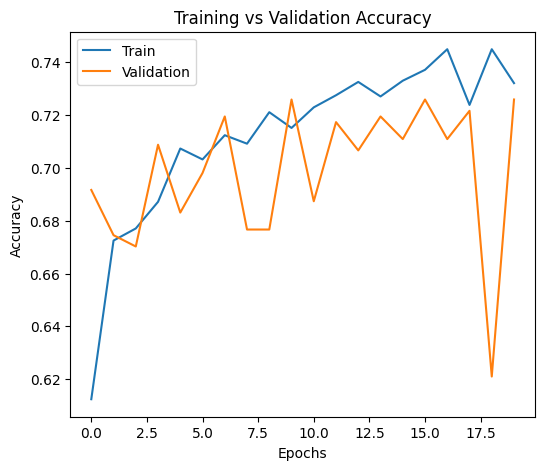

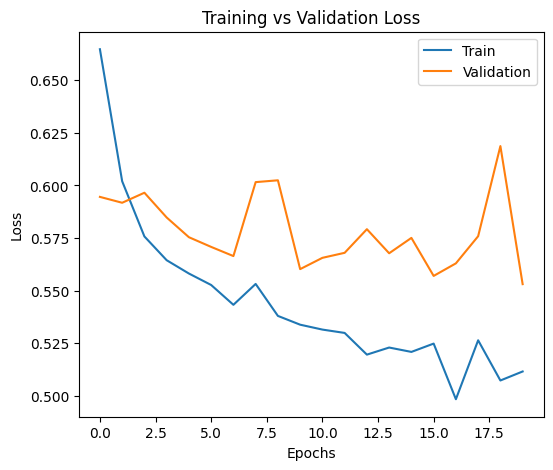

In [17]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(6,5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss Plot
plt.figure(figsize=(6,5))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()


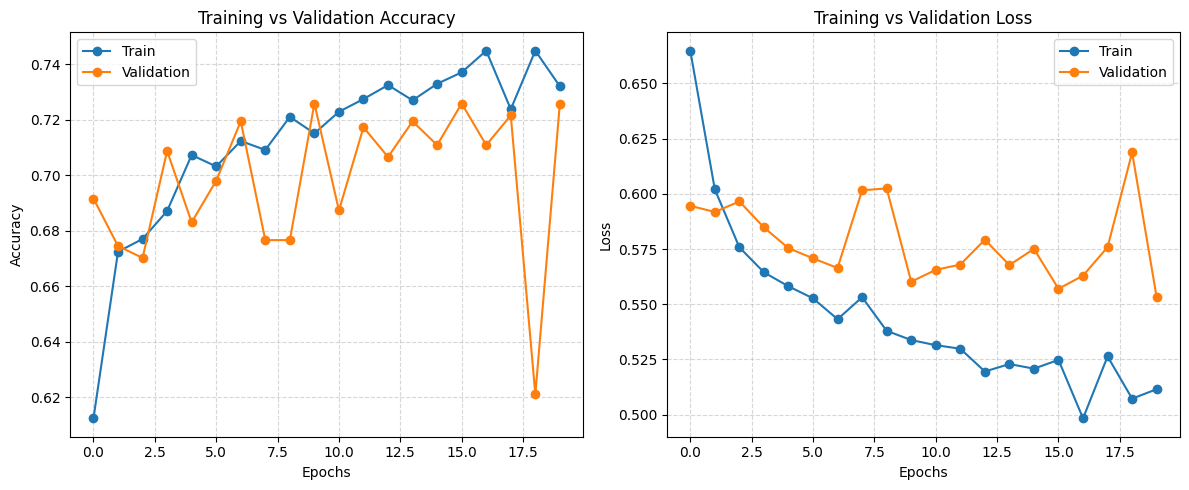

In [60]:
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
plt.figure(figsize=(12,5))

# Accuracy Plot (left)
plt.subplot(1, 2, 1)  # 1 row, 2 columns, subplot 1
plt.plot(history.history["accuracy"], marker='o')
plt.plot(history.history["val_accuracy"], marker='o')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid(True, linestyle='--', alpha=0.5)

# Loss Plot (right)
plt.subplot(1, 2, 2)  # 1 row, 2 columns, subplot 2
plt.plot(history.history["loss"], marker='o')
plt.plot(history.history["val_loss"], marker='o')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()  # Adjust spacing
plt.show()


15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 868ms/step


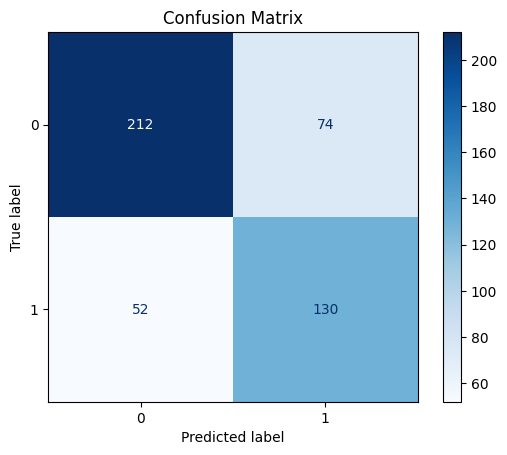

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = model.predict(test_gen)
y_pred_classes = (y_pred > 0.5).astype("int32")

cm = confusion_matrix(test_gen.classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step


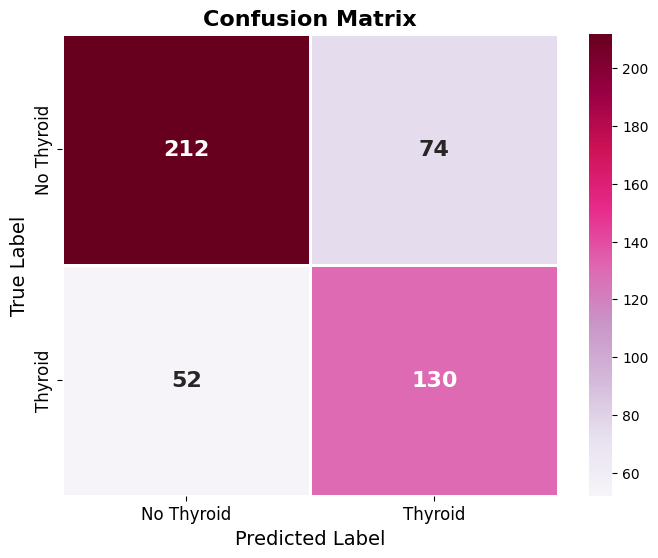

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# STEP 1: Predict on Test Data
y_pred = model.predict(test_gen)
y_pred = (y_pred > 0.5).astype(int)  # convert probabilities → 0/1

# STEP 2: True labels
y_true = test_gen.classes

# STEP 3: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# STEP 4: Plot Confusion Matrix (High-Quality)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", linewidths=2, linecolor='white',
            cbar=True, annot_kws={"size":16, "weight":"bold"})

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16, weight='bold')
plt.xticks(np.arange(2)+0.5, ["No Thyroid", "Thyroid"], fontsize=12)
plt.yticks(np.arange(2)+0.5, ["No Thyroid", "Thyroid"], fontsize=12)
plt.show()


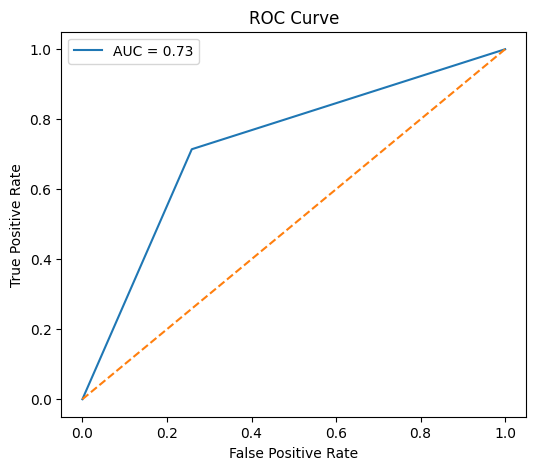

In [20]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(test_gen.classes, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [25]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Get the VGG16 model from Sequential
    vgg = model.get_layer("vgg16")
    last_conv_layer = vgg.get_layer(last_conv_layer_name)

    # Full model for Grad-CAM
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        target_class = tf.argmax(predictions[0])  # predicted class
        loss = predictions[:, target_class]

    grads = tape.gradient(loss, conv_outputs)

    # Global Average Pooling to get importance weights
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)

    heatmap = np.maximum(heatmap, 0)  # ReLU
    heatmap /= tf.reduce_max(heatmap) + 1e-9

    return heatmap.numpy()


In [34]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)


0 vgg16 Functional
1 flatten Flatten
2 dense Dense
3 dropout Dropout
4 dense_1 Dense


In [50]:
model.summary()
print("Input structure:", model.input)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,983,813 (129.64 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 12,846,084 (49.00 MB)

Input structure: <KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_19>


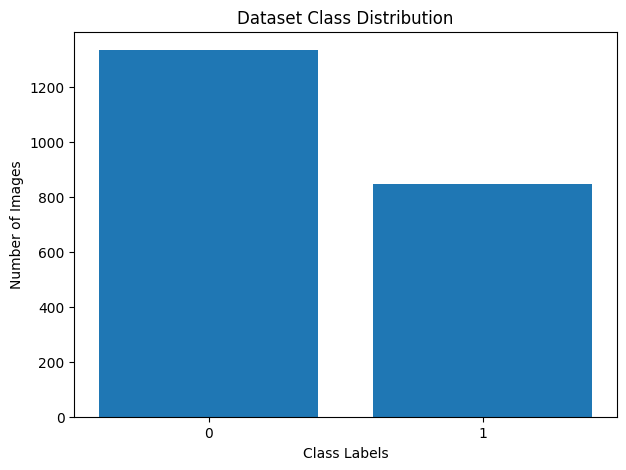

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Use your train generator
labels = list(train_gen.class_indices.keys())
counts = [0] * len(labels)

# Count images in each class
for cls, idx in train_gen.class_indices.items():
    counts[idx] = len(os.listdir(os.path.join(train_gen.directory, cls)))


# Plot
plt.figure(figsize=(7,5))
plt.bar(labels, counts)
plt.xlabel("Class Labels")
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution")
plt.show()


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step


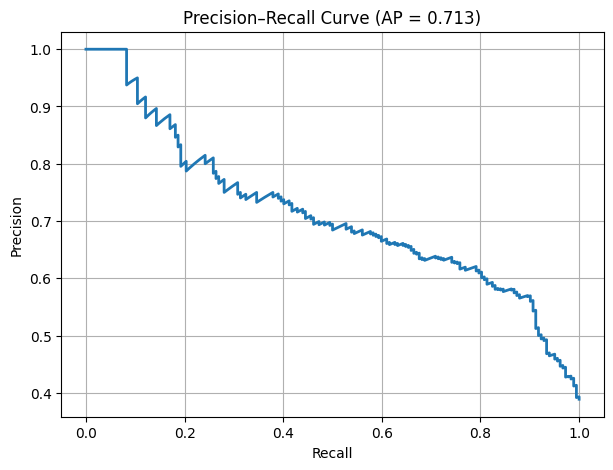

In [53]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Get predictions on test set ---
y_true = test_gen.classes                    # true labels
y_pred = model.predict(test_gen).ravel()     # predicted probabilities

# --- Step 2: Compute PR Curve ---
precision, recall, thresholds = precision_recall_curve(y_true, y_pred)

# Average Precision Score
ap = average_precision_score(y_true, y_pred)

# --- Step 3: Plot ---
plt.figure(figsize=(7,5))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (AP = {ap:.3f})")
plt.grid(True)
plt.show()


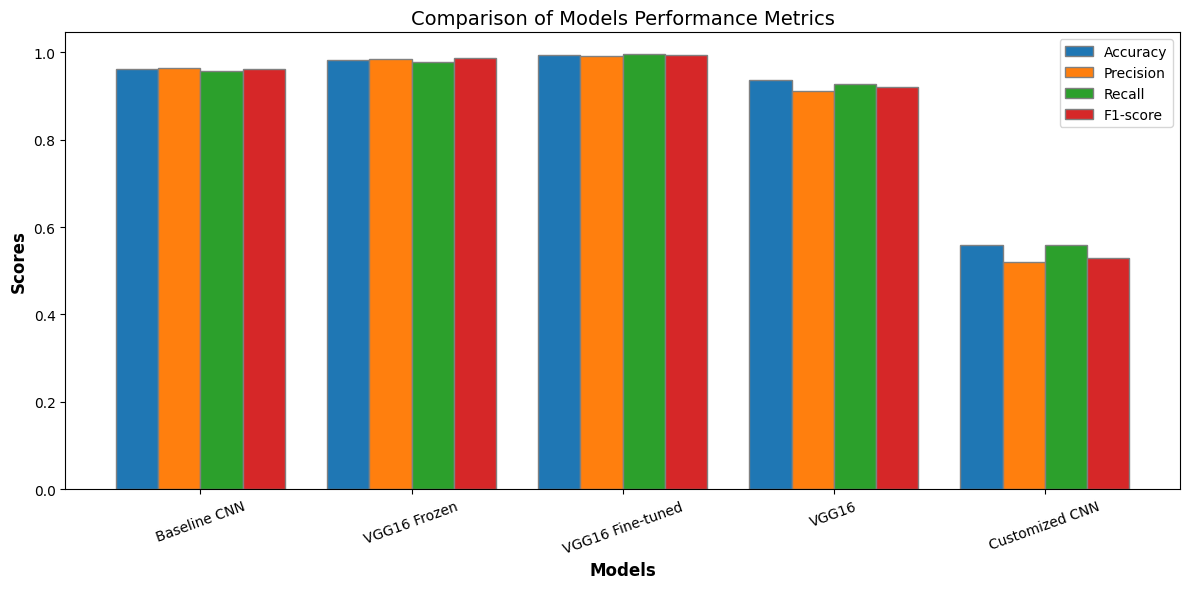

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data
models = ['Baseline CNN', 'VGG16 Frozen', 'VGG16 Fine-tuned', 'VGG16', 'Customized CNN']
accuracy = [0.9625, 0.9812, 0.9937, 0.9360, 0.56]
precision = [0.9650, 0.9845, 0.9921, 0.9120, 0.52]
recall = [0.9572, 0.9768, 0.9958, 0.9280, 0.56]
f1_score = [0.9611, 0.9860, 0.9939, 0.9200, 0.53]

# Create DataFrame
df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1_score
})

# Set figure size
plt.figure(figsize=(12, 6))

# Set position of bar on X axis
bar_width = 0.2
r1 = np.arange(len(models))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]
r4 = [x + bar_width for x in r3]

# Make the bar plots
plt.bar(r1, df['Accuracy'], width=bar_width, edgecolor='grey', label='Accuracy')
plt.bar(r2, df['Precision'], width=bar_width, edgecolor='grey', label='Precision')
plt.bar(r3, df['Recall'], width=bar_width, edgecolor='grey', label='Recall')
plt.bar(r4, df['F1-score'], width=bar_width, edgecolor='grey', label='F1-score')

# Add xticks on the middle of the group bars
plt.xlabel('Models', fontweight='bold', fontsize=12)
plt.ylabel('Scores', fontweight='bold', fontsize=12)
plt.xticks([r + 1.5*bar_width for r in range(len(models))], df['Model'], rotation=20)

# Add legend
plt.legend()

# Add title
plt.title('Comparison of Models Performance Metrics', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()


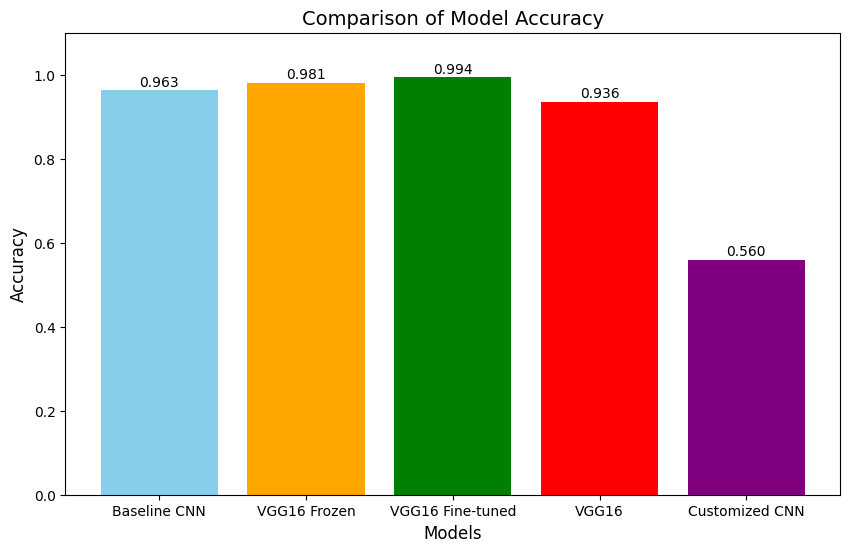

In [55]:
import matplotlib.pyplot as plt

# Data
models = ['Baseline CNN', 'VGG16 Frozen', 'VGG16 Fine-tuned', 'VGG16', 'Customized CNN']
accuracy = [0.9625, 0.9812, 0.9937, 0.9360, 0.56]

# Plotting
plt.figure(figsize=(10,6))
bars = plt.bar(models, accuracy, color=['skyblue', 'orange', 'green', 'red', 'purple'])

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', fontsize=10)

# Labels and title
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.title('Comparison of Model Accuracy', fontsize=14)
plt.ylim(0, 1.1)  # Set y-axis limit slightly above 1

plt.show()


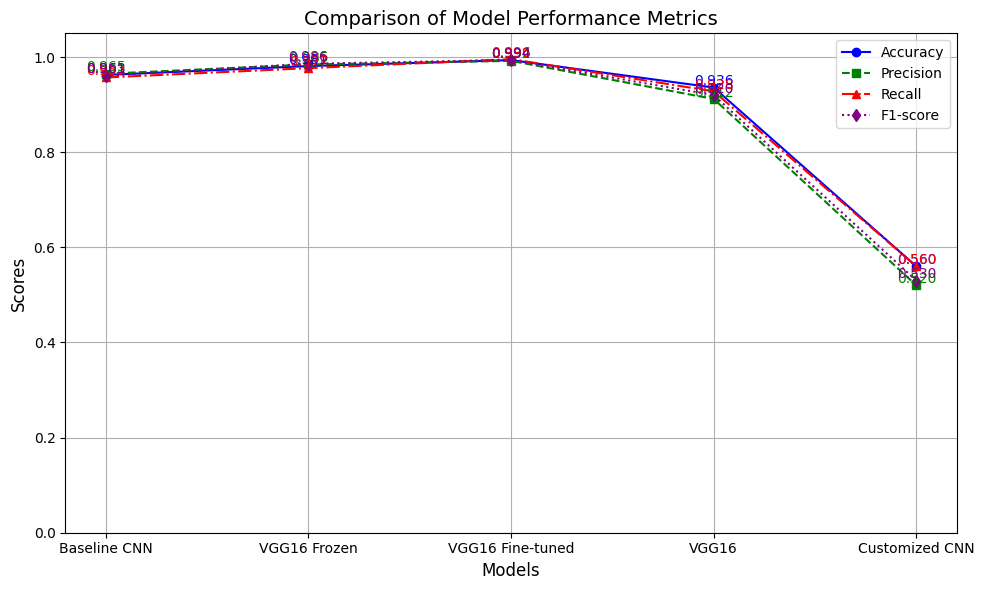

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
models = ['Baseline CNN', 'VGG16 Frozen', 'VGG16 Fine-tuned', 'VGG16', 'Customized CNN']
accuracy = [0.9625, 0.9812, 0.9937, 0.9360, 0.56]
precision = [0.9650, 0.9845, 0.9921, 0.9120, 0.52]
recall = [0.9572, 0.9768, 0.9958, 0.9280, 0.56]
f1_score = [0.9611, 0.9860, 0.9939, 0.9200, 0.53]

# Create DataFrame
df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1_score
})

# Plotting
plt.figure(figsize=(10,6))

plt.plot(df['Model'], df['Accuracy'], marker='o', linestyle='-', color='blue', label='Accuracy')
plt.plot(df['Model'], df['Precision'], marker='s', linestyle='--', color='green', label='Precision')
plt.plot(df['Model'], df['Recall'], marker='^', linestyle='-.', color='red', label='Recall')
plt.plot(df['Model'], df['F1-score'], marker='d', linestyle=':', color='purple', label='F1-score')

# Add values on top of points
for i in range(len(models)):
    plt.text(i, accuracy[i]+0.005, f'{accuracy[i]:.3f}', ha='center', color='blue')
    plt.text(i, precision[i]+0.005, f'{precision[i]:.3f}', ha='center', color='green')
    plt.text(i, recall[i]+0.005, f'{recall[i]:.3f}', ha='center', color='red')
    plt.text(i, f1_score[i]+0.005, f'{f1_score[i]:.3f}', ha='center', color='purple')

# Labels and title
plt.xlabel('Models', fontsize=12)
plt.ylabel('Scores', fontsize=12)
plt.title('Comparison of Model Performance Metrics', fontsize=14)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


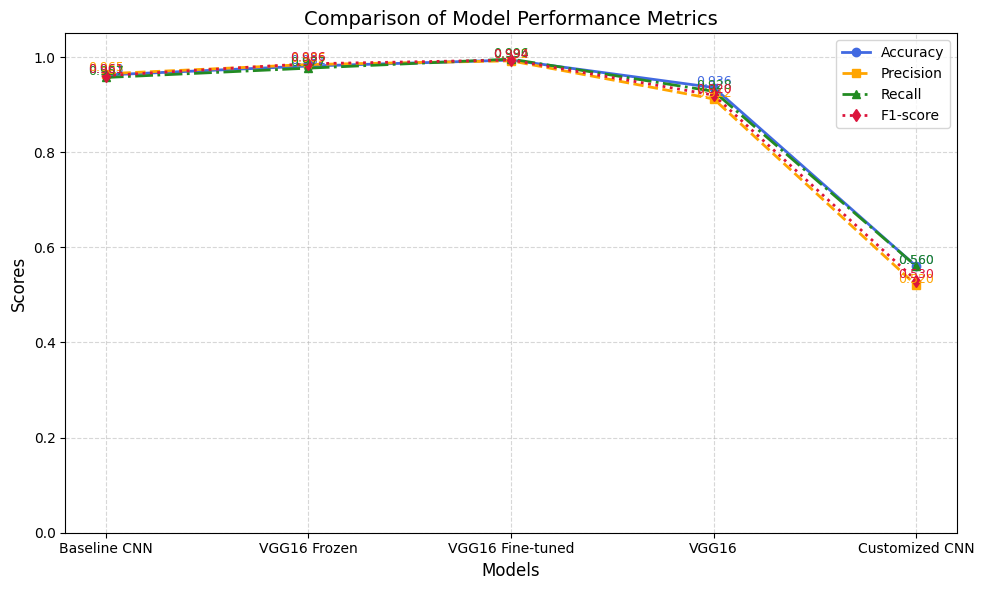

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
models = ['Baseline CNN', 'VGG16 Frozen', 'VGG16 Fine-tuned', 'VGG16', 'Customized CNN']
accuracy = [0.9625, 0.9812, 0.9937, 0.9360, 0.56]
precision = [0.9650, 0.9845, 0.9921, 0.9120, 0.52]
recall = [0.9572, 0.9768, 0.9958, 0.9280, 0.56]
f1_score = [0.9611, 0.9860, 0.9939, 0.9200, 0.53]

# Create DataFrame
df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1_score
})

# Plotting
plt.figure(figsize=(10,6))

# Plot each metric with a different color and marker
plt.plot(df['Model'], df['Accuracy'], marker='o', linestyle='-', color='royalblue', linewidth=2, label='Accuracy')
plt.plot(df['Model'], df['Precision'], marker='s', linestyle='--', color='orange', linewidth=2, label='Precision')
plt.plot(df['Model'], df['Recall'], marker='^', linestyle='-.', color='forestgreen', linewidth=2, label='Recall')
plt.plot(df['Model'], df['F1-score'], marker='d', linestyle=':', color='crimson', linewidth=2, label='F1-score')

# Add values on top of points
for i in range(len(models)):
    plt.text(i, accuracy[i]+0.005, f'{accuracy[i]:.3f}', ha='center', color='royalblue', fontsize=9)
    plt.text(i, precision[i]+0.005, f'{precision[i]:.3f}', ha='center', color='orange', fontsize=9)
    plt.text(i, recall[i]+0.005, f'{recall[i]:.3f}', ha='center', color='forestgreen', fontsize=9)
    plt.text(i, f1_score[i]+0.005, f'{f1_score[i]:.3f}', ha='center', color='crimson', fontsize=9)

# Labels, title, grid
plt.xlabel('Models', fontsize=12)
plt.ylabel('Scores', fontsize=12)
plt.title('Comparison of Model Performance Metrics', fontsize=14)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


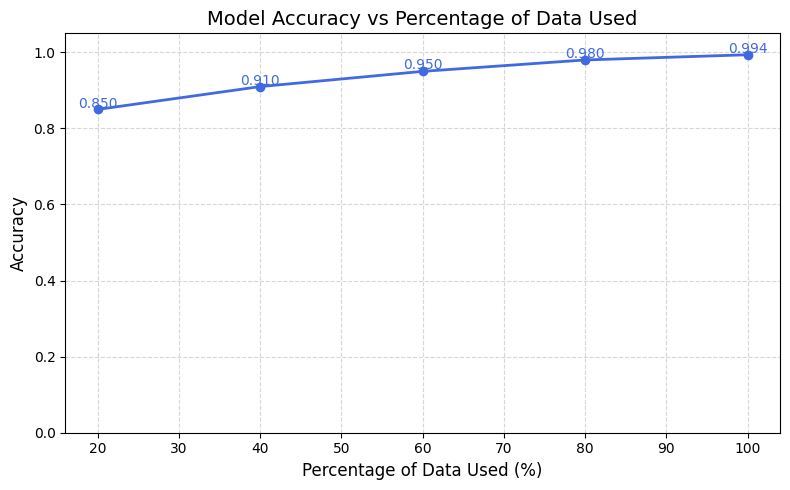

In [59]:
import matplotlib.pyplot as plt

# Example data (replace with your actual values)
data_percentage = [20, 40, 60, 80, 100]  # Percentage of data used for training
accuracy = [0.85, 0.91, 0.95, 0.98, 0.9937]  # Accuracy of the model at each percentage

# Plotting
plt.figure(figsize=(8,5))
plt.plot(data_percentage, accuracy, marker='o', linestyle='-', color='royalblue', linewidth=2)

# Add values on top of points
for i, val in enumerate(accuracy):
    plt.text(data_percentage[i], val + 0.005, f'{val:.3f}', ha='center', fontsize=10, color='royalblue')

# Labels and title
plt.xlabel('Percentage of Data Used (%)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy vs Percentage of Data Used', fontsize=14)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
